Dataset: 4478 rows, 28 features
Train: 3582 rows | Validation: 896 rows
[100]	valid_0's l1: 0.197393
[200]	valid_0's l1: 0.168978
[300]	valid_0's l1: 0.164488
[400]	valid_0's l1: 0.16279
[500]	valid_0's l1: 0.161593

  MAE            : 0.161 min
  Best iteration : 507

Sample predictions (first 10):
 actual  predicted  error
   16.4      15.59   0.81
    5.8       5.64   0.16
    1.0       0.83   0.17
    1.9       1.98   0.08
    2.0       2.37   0.37
    1.1       0.80   0.30
   12.0      12.17   0.17
    0.4       0.40   0.00
    8.1       7.85   0.25
    0.2       0.18   0.02

Feature Importance (top 15):
  prev_stop_delay                     ██████████████████████████████
  speed_factor                        ████████████████████
  distance_from_prev_km               ████████████████
  temperature_c                       ███████████
  wind_speed_kmh                      ██████████
  humidity_pct                        ██████████
  stop_sequence                       ██████████
  h

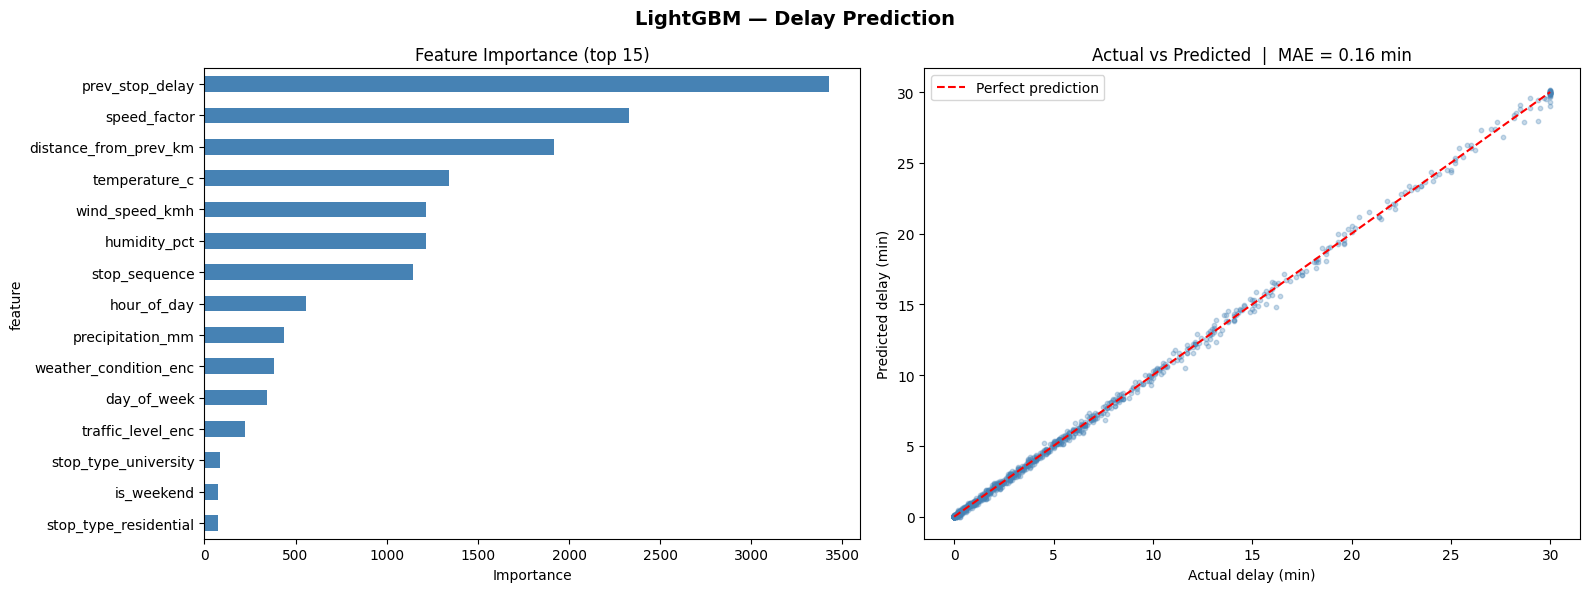

✅ Saved: data/model1_lgbm_results.png
✅ Saved: models/delay_model.pkl


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib
import os

# ── 1. LOAD ───────────────────────────────────────────────────
df = pd.read_csv('../data/model1_dataset.csv')

X = df.drop(columns=['target_delay_min', 'traffic_level', 'weather_condition'])
y = df['target_delay_min']

print(f"Dataset: {X.shape[0]} rows, {X.shape[1]} features")

# ── 2. TRAIN / VALIDATION SPLIT ───────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} rows | Validation: {len(X_val)} rows")

# ── 3. TRAIN ──────────────────────────────────────────────────
model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_child_samples=20,
    verbose=-1,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

# ── 4. EVALUATE ───────────────────────────────────────────────
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)

print(f"\n{'='*45}")
print(f"  MAE            : {mae:.3f} min")
print(f"  Best iteration : {model.best_iteration_}")
print(f"{'='*45}")

# Sample predictions
results = pd.DataFrame({
    'actual':    y_val.values,
    'predicted': y_pred.round(2)
})
results['error'] = (results['actual'] - results['predicted']).abs().round(2)
print(f"\nSample predictions (first 10):")
print(results.head(10).to_string(index=False))

# ── 5. FEATURE IMPORTANCE ─────────────────────────────────────
importance = pd.DataFrame({
    'feature':    X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f"\nFeature Importance (top 15):")
print("=" * 45)
for _, row in importance.head(15).iterrows():
    bar = '█' * int(row['importance'] / importance['importance'].max() * 30)
    print(f"  {row['feature']:<35} {bar}")

# ── 6. PLOTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM — Delay Prediction', fontsize=14, fontweight='bold')

# Feature importance
importance.head(15).plot(
    kind='barh', x='feature', y='importance',
    ax=axes[0], legend=False, color='steelblue'
)
axes[0].set_title('Feature Importance (top 15)')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Actual vs Predicted scatter
axes[1].scatter(y_val, y_pred, alpha=0.3, color='steelblue', s=10)
axes[1].plot([0, 30], [0, 30], 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual delay (min)')
axes[1].set_ylabel('Predicted delay (min)')
axes[1].set_title(f'Actual vs Predicted  |  MAE = {mae:.2f} min')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/model1_lgbm_results.png', dpi=150)
plt.show()
print("✅ Saved: data/model1_lgbm_results.png")

# ── 7. SAVE MODEL ─────────────────────────────────────────────
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/delay_model.pkl')
print("✅ Saved: models/delay_model.pkl")

Unique trips  : 350
Train trips   : 280 → 3583 rows
Val trips     : 70   → 895 rows
[100]	valid_0's l1: 0.199423
[200]	valid_0's l1: 0.179206
[300]	valid_0's l1: 0.175197
[400]	valid_0's l1: 0.174152
[500]	valid_0's l1: 0.173405

  MAE random split  : 0.162 min
  MAE trip split    : 0.173 min
  Difference        : 0.011 min
  ✅ Model generalizes well across unseen trips

Feature Importance (top 15):
  prev_stop_delay                     ██████████████████████████████
  speed_factor                        ████████████████████
  distance_from_prev_km               ████████████████
  temperature_c                       ██████████
  wind_speed_kmh                      ██████████
  stop_sequence                       █████████
  humidity_pct                        ████████
  hour_of_day                         █████
  precipitation_mm                    ███
  weather_condition_enc               ███
  day_of_week                         ██
  traffic_level_enc                   █
  stop_type_

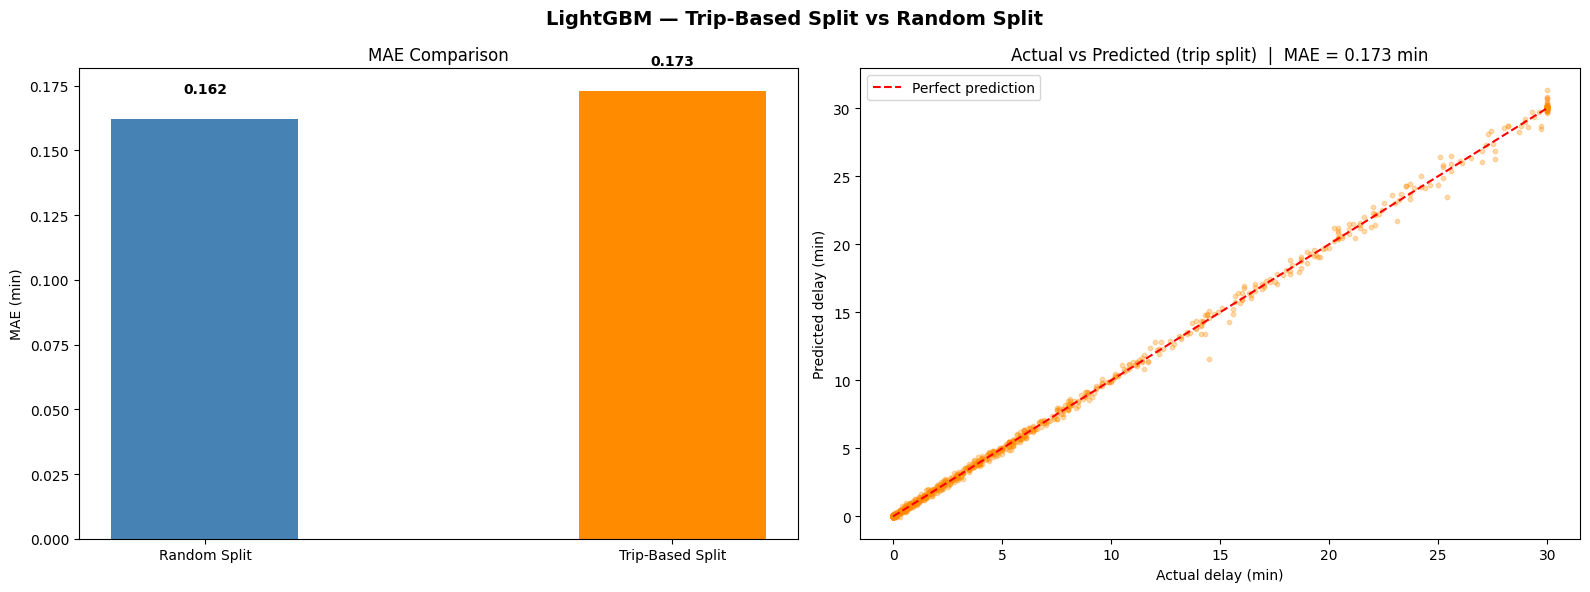

✅ Saved: data/model1_trip_split_results.png
✅ Saved: models/delay_model.pkl


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import joblib
import os

# ── 1. LOAD ───────────────────────────────────────────────────
df = pd.read_csv('../data/model1_dataset.csv')
arrivals = pd.read_csv('../data/stop_arrivals.csv')[['trip_id', 'observation_id']]

# Add trip_id back to dataset (same row order)
df_with_trip = df.copy()
df_with_trip['trip_id'] = arrivals['trip_id'].values

X = df.drop(columns=['target_delay_min', 'traffic_level', 'weather_condition'])
y = df['target_delay_min']

# ── 2. TRIP-BASED SPLIT ───────────────────────────────────────
unique_trips = df_with_trip['trip_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_trips)

split_idx = int(len(unique_trips) * 0.8)
train_trips = set(unique_trips[:split_idx])
val_trips   = set(unique_trips[split_idx:])

train_mask = df_with_trip['trip_id'].isin(train_trips)
val_mask   = df_with_trip['trip_id'].isin(val_trips)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Unique trips  : {len(unique_trips)}")
print(f"Train trips   : {len(train_trips)} → {len(X_train)} rows")
print(f"Val trips     : {len(val_trips)}   → {len(X_val)} rows")

# ── 3. TRAIN ──────────────────────────────────────────────────
model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_child_samples=20,
    verbose=-1,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

# ── 4. EVALUATE ───────────────────────────────────────────────
y_pred = model.predict(X_val)
mae_trip  = mean_absolute_error(y_val, y_pred)

# Also compute random split MAE for comparison
from sklearn.model_selection import train_test_split
X_tr, X_v, y_tr, y_v = train_test_split(X, y, test_size=0.2, random_state=42)
model_random = lgb.LGBMRegressor(
    objective='regression', metric='mae', n_estimators=model.best_iteration_,
    learning_rate=0.05, num_leaves=31, feature_fraction=0.8,
    bagging_fraction=0.8, bagging_freq=5, min_child_samples=20,
    verbose=-1, random_state=42
)
model_random.fit(X_tr, y_tr)
mae_random = mean_absolute_error(y_v, model_random.predict(X_v))

print(f"\n{'='*45}")
print(f"  MAE random split  : {mae_random:.3f} min")
print(f"  MAE trip split    : {mae_trip:.3f} min")
print(f"  Difference        : {mae_trip - mae_random:.3f} min")
if mae_trip < 1.0:
    print(f"  ✅ Model generalizes well across unseen trips")
else:
    print(f"  ⚠️  Random split was overly optimistic")
print(f"{'='*45}")

# ── 5. FEATURE IMPORTANCE ─────────────────────────────────────
importance = pd.DataFrame({
    'feature':    X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f"\nFeature Importance (top 15):")
print("=" * 45)
for _, row in importance.head(15).iterrows():
    bar = '█' * int(row['importance'] / importance['importance'].max() * 30)
    print(f"  {row['feature']:<35} {bar}")

# ── 6. PLOTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM — Trip-Based Split vs Random Split', fontsize=14, fontweight='bold')

# MAE comparison bar
axes[0].bar(
    ['Random Split', 'Trip-Based Split'],
    [mae_random, mae_trip],
    color=['steelblue', 'darkorange'], width=0.4
)
axes[0].set_ylabel('MAE (min)')
axes[0].set_title('MAE Comparison')
for i, v in enumerate([mae_random, mae_trip]):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Actual vs Predicted (trip split)
axes[1].scatter(y_val, y_pred, alpha=0.3, color='darkorange', s=10)
axes[1].plot([0, 30], [0, 30], 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual delay (min)')
axes[1].set_ylabel('Predicted delay (min)')
axes[1].set_title(f'Actual vs Predicted (trip split)  |  MAE = {mae_trip:.3f} min')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/model1_trip_split_results.png', dpi=150)
plt.show()
print("✅ Saved: data/model1_trip_split_results.png")

# ── 7. SAVE BEST MODEL ────────────────────────────────────────
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/delay_model.pkl')
print("✅ Saved: models/delay_model.pkl")

Train: 3583 rows | Val: 895 rows

  Model                       MAE   MAE (sec)
  ----------------------------------------
  Linear Regression         1.479      88.8 sec
  Ridge                     1.479      88.7 sec
  Lasso                     1.438      86.3 sec
  KNN                       1.027      61.6 sec
  Decision Tree             0.272      16.3 sec
  Random Forest             0.178      10.7 sec
  LightGBM                  0.173      10.4 sec

🏆 Best model: LightGBM  MAE = 0.173 min


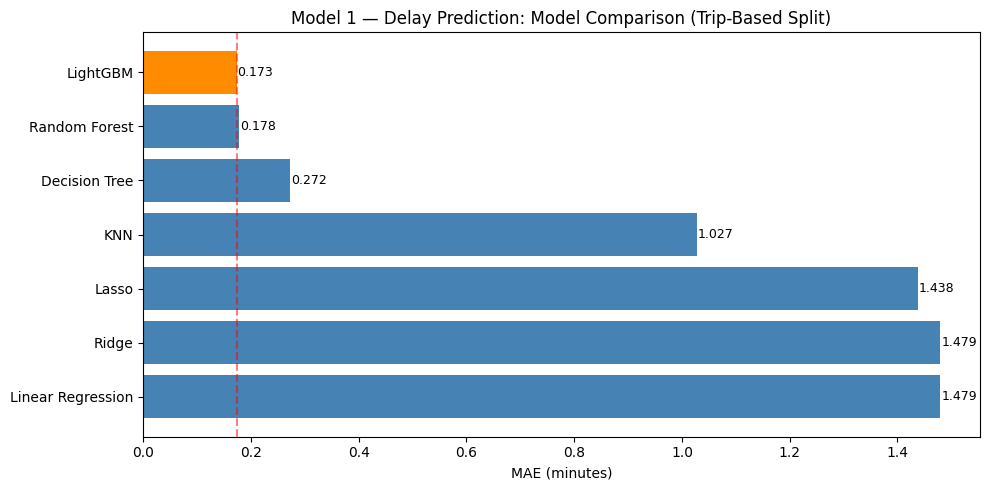

✅ Saved: data/model1_comparison.png
✅ Saved: models/delay_model_other.pkl  (LightGBM)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import joblib
import os

# ── 1. LOAD ───────────────────────────────────────────────────
df_full   = pd.read_csv('../data/model1_dataset.csv')        # 31 cols — tree models
df_linear = pd.read_csv('../data/model1_dataset_linear.csv') # 13 cols — linear/knn

arrivals  = pd.read_csv('../data/stop_arrivals.csv')[['trip_id']]

# ── 2. TRIP-BASED SPLIT FUNCTION ──────────────────────────────
def trip_split(df, test_size=0.2, seed=42):
    df_tmp = df.copy()
    df_tmp['trip_id'] = arrivals['trip_id'].values

    unique_trips = df_tmp['trip_id'].unique()
    np.random.seed(seed)
    np.random.shuffle(unique_trips)

    split_idx    = int(len(unique_trips) * (1 - test_size))
    train_trips  = set(unique_trips[:split_idx])
    val_trips    = set(unique_trips[split_idx:])

    train_mask = df_tmp['trip_id'].isin(train_trips)
    val_mask   = df_tmp['trip_id'].isin(val_trips)
    return train_mask, val_mask

# ── 3. PREPARE DATA ───────────────────────────────────────────
# Full dataset (tree models)
train_mask, val_mask = trip_split(df_full)

X_full = df_full.drop(columns=['target_delay_min', 'traffic_level', 'weather_condition'])
y_full = df_full['target_delay_min']

X_train_f, y_train_f = X_full[train_mask], y_full[train_mask]
X_val_f,   y_val_f   = X_full[val_mask],   y_full[val_mask]

# Linear dataset (linear/knn models) — same trip split
X_lin = df_linear.drop(columns=['target_delay_min'])
y_lin = df_linear['target_delay_min']

X_train_l, y_train_l = X_lin[train_mask], y_lin[train_mask]
X_val_l,   y_val_l   = X_lin[val_mask],   y_lin[val_mask]

# Scaled version for Linear + KNN
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_l)
X_val_s   = scaler.transform(X_val_l)

print(f"Train: {train_mask.sum()} rows | Val: {val_mask.sum()} rows")

# ── 4. DEFINE MODELS ──────────────────────────────────────────
models = {
    'Linear Regression': (LinearRegression(),          X_train_s, X_val_s, y_train_l, y_val_l),
    'Ridge':             (Ridge(alpha=1.0),             X_train_s, X_val_s, y_train_l, y_val_l),
    'Lasso':             (Lasso(alpha=0.1),             X_train_s, X_val_s, y_train_l, y_val_l),
    'KNN':               (KNeighborsRegressor(n_neighbors=5), X_train_s, X_val_s, y_train_l, y_val_l),
    'Decision Tree':     (DecisionTreeRegressor(max_depth=8, random_state=42), X_train_f, X_val_f, y_train_f, y_val_f),
    'Random Forest':     (RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1), X_train_f, X_val_f, y_train_f, y_val_f),
    'LightGBM':          (lgb.LGBMRegressor(
                            objective='regression', metric='mae',
                            n_estimators=500, learning_rate=0.05,
                            num_leaves=31, feature_fraction=0.8,
                            bagging_fraction=0.8, bagging_freq=5,
                            verbose=-1, random_state=42),
                          X_train_f, X_val_f, y_train_f, y_val_f),
}

# ── 5. TRAIN & EVALUATE ALL ───────────────────────────────────
results = {}

print(f"\n{'='*45}")
print(f"  {'Model':<22} {'MAE':>8}  {'MAE (sec)':>10}")
print(f"  {'-'*40}")

for name, (model, Xtr, Xv, ytr, yv) in models.items():
    model.fit(Xtr, ytr)
    mae = mean_absolute_error(yv, model.predict(Xv))
    results[name] = mae
    print(f"  {name:<22} {mae:>8.3f}  {mae*60:>8.1f} sec")

print(f"{'='*45}")

best_model_name = min(results, key=results.get)
print(f"\n🏆 Best model: {best_model_name}  MAE = {results[best_model_name]:.3f} min")

# ── 6. PLOT ───────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
names = list(results.keys())
maes  = list(results.values())
colors = ['darkorange' if n == best_model_name else 'steelblue' for n in names]

bars = plt.barh(names, maes, color=colors)
plt.xlabel('MAE (minutes)')
plt.title('Model 1 — Delay Prediction: Model Comparison (Trip-Based Split)')
plt.axvline(x=min(maes), color='red', linestyle='--', alpha=0.5)
for bar, val in zip(bars, maes):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/model1_comparison.png', dpi=150)
plt.show()
print("✅ Saved: data/model1_comparison.png")

# ── 7. SAVE BEST MODEL ────────────────────────────────────────
os.makedirs('../models', exist_ok=True)
best_model = models[best_model_name][0]
joblib.dump(best_model, '../models/delay_model_other.pkl')
print(f"✅ Saved: models/delay_model_other.pkl  ({best_model_name})")

In [13]:
import joblib
model = joblib.load('../models/delay_model.pkl')
print(type(model).__name__)
print(model.get_params())

LGBMRegressor
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 1000, 'n_jobs': None, 'num_leaves': 31, 'objective': 'regression', 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'metric': 'mae', 'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbose': -1}


In [16]:
import joblib

model_1000 = joblib.load('../models/delay_model.pkl')
print('delay_model best iteration:', model_1000.best_iteration_)


delay_model best iteration: 464


In [17]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

model = joblib.load('../models/delay_model.pkl')

# Check iterations
print('best_iteration_:', model.best_iteration_)
print('n_estimators param:', model.n_estimators)

# Load data and test both splits to see which MAE matches
df = pd.read_csv('../data/model1_dataset.csv')
arrivals = pd.read_csv('../data/stop_arrivals.csv')[['trip_id']]

X = df.drop(columns=['target_delay_min', 'traffic_level', 'weather_condition'])
y = df['target_delay_min']

df_tmp = df.copy()
df_tmp['trip_id'] = arrivals['trip_id'].values

# Trip split
unique_trips = df_tmp['trip_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_trips)
split_idx = int(len(unique_trips) * 0.8)
val_trips = set(unique_trips[split_idx:])
val_mask_trip = df_tmp['trip_id'].isin(val_trips)

# Random split
from sklearn.model_selection import train_test_split
_, X_val_r, _, y_val_r = train_test_split(X, y, test_size=0.2, random_state=42)

# MAE on trip val
mae_trip = mean_absolute_error(y[val_mask_trip], model.predict(X[val_mask_trip]))

# MAE on random val
mae_random = mean_absolute_error(y_val_r, model.predict(X_val_r))

print(f'\nMAE on trip val set    : {mae_trip:.3f}')
print(f'MAE on random val set  : {mae_random:.3f}')
print()
print('Trip based kodun MAE   : 0.173')
print('Random split kodun MAE : 0.162')
print()
print('Hangisine daha yakınsa o split ile eğitilmiş.')

best_iteration_: 464
n_estimators param: 1000

MAE on trip val set    : 0.173
MAE on random val set  : 0.098

Trip based kodun MAE   : 0.173
Random split kodun MAE : 0.162

Hangisine daha yakınsa o split ile eğitilmiş.


Unique trips       : 350
Train trips        : 280
Validation trips   : 70
Train rows         : 3583
Validation rows    : 895
Trip overlap       : 0

Training LightGBM on TRIP-BASED split...


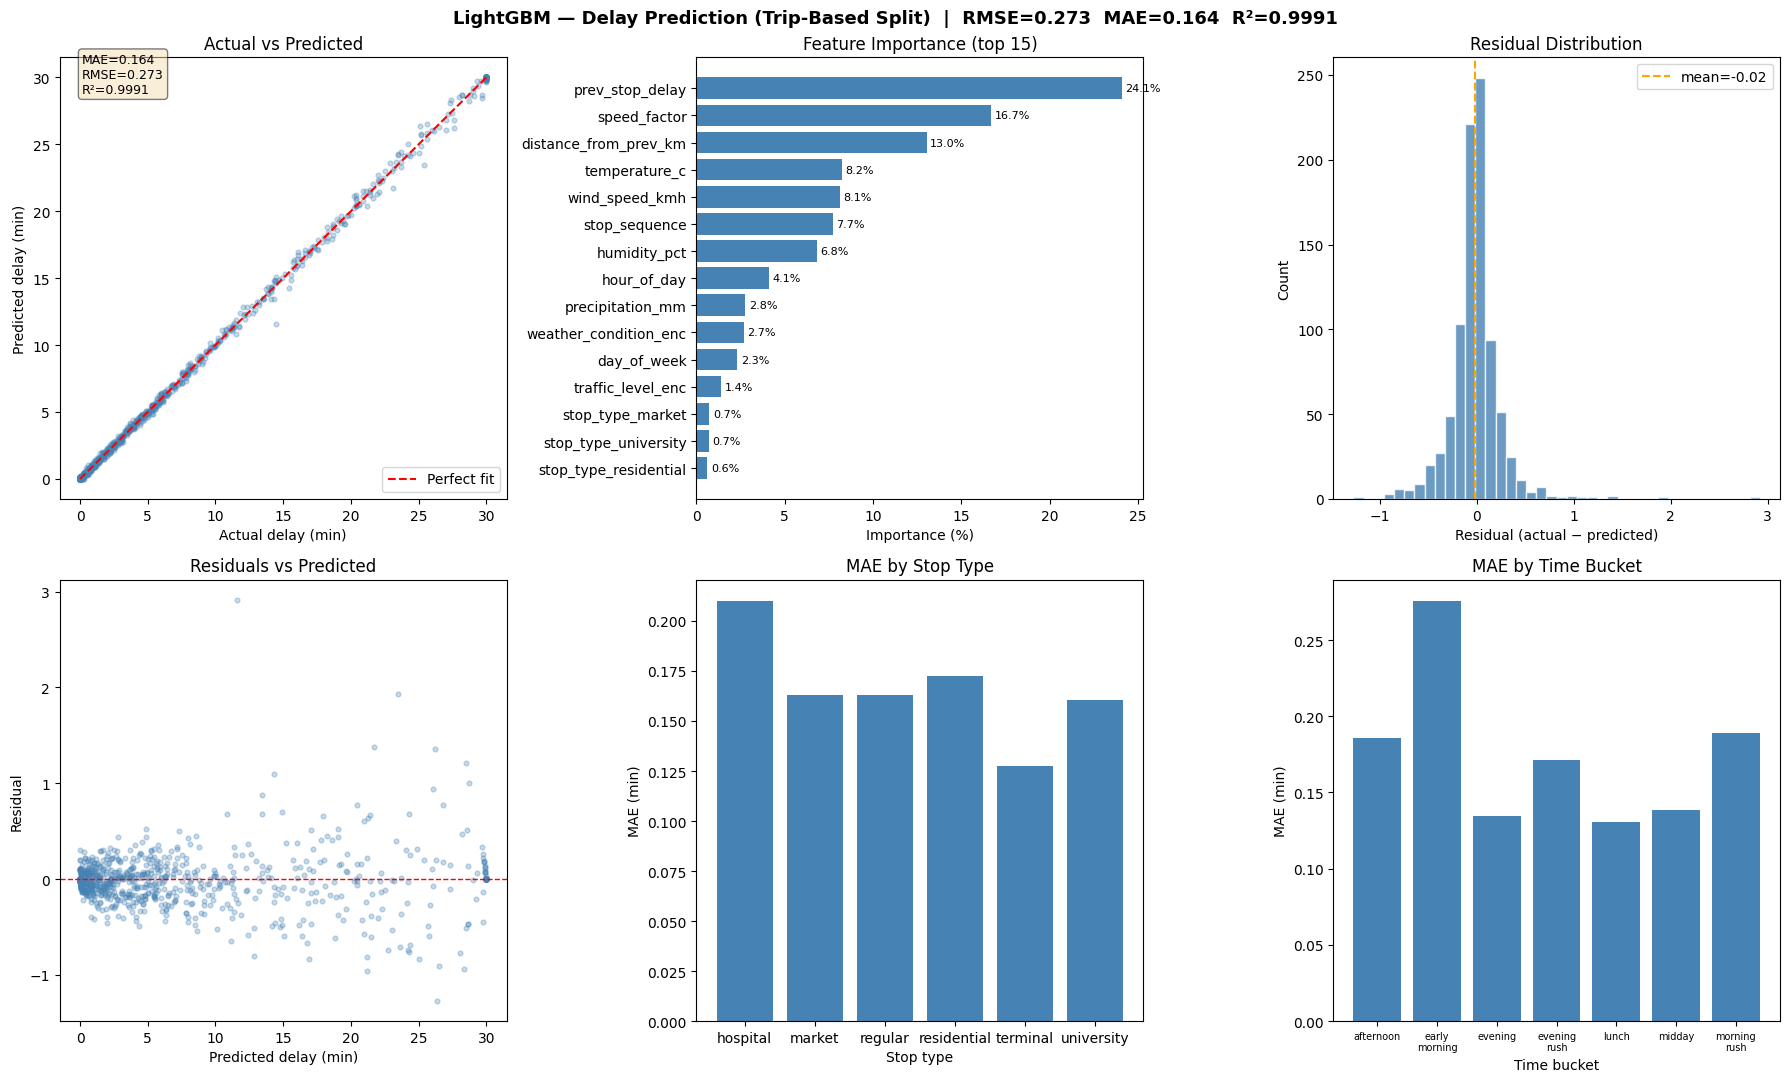

✅ Saved: ../data/results/model1_lightgbm_trip_based_results.png
   TRIP-BASED RESULTS -> MAE=0.164  RMSE=0.273  R²=0.9991

Training Random Forest on TRIP-BASED split...


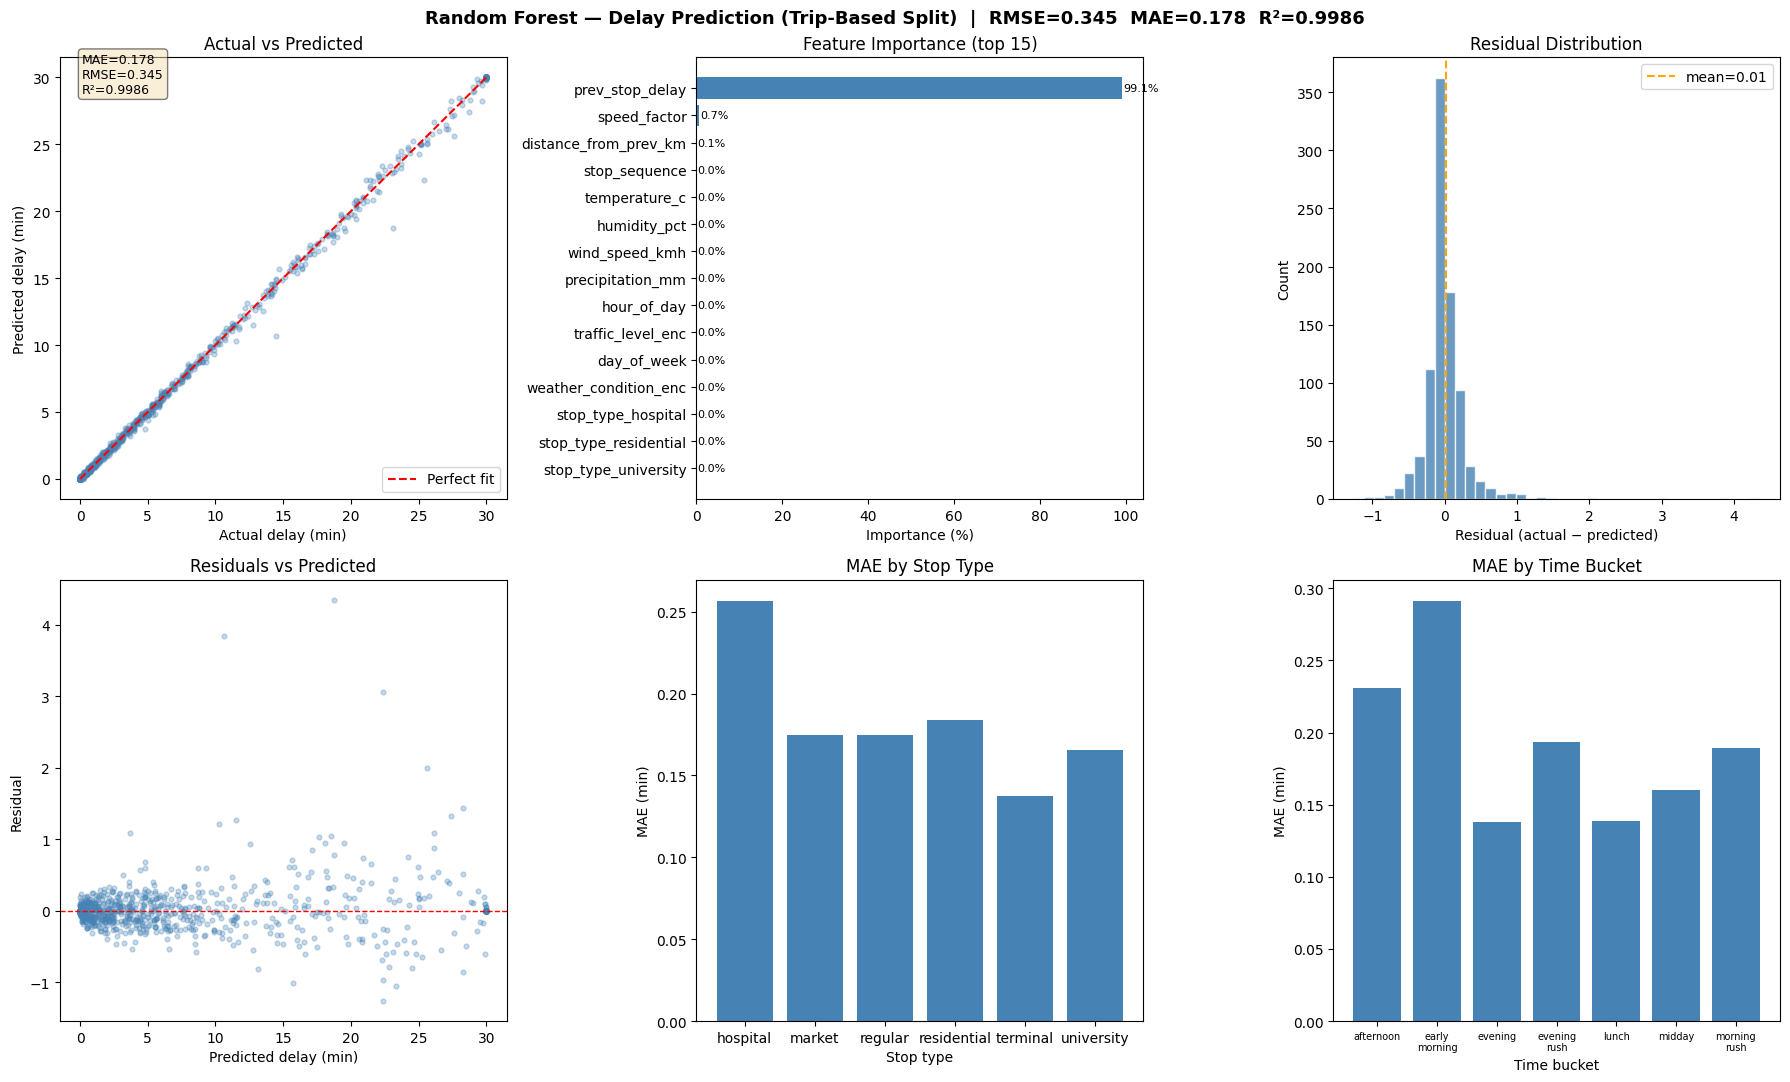

✅ Saved: ../data/results/model1_random_forest_trip_based_results.png
   TRIP-BASED RESULTS -> MAE=0.178  RMSE=0.345  R²=0.9986

Training Decision Tree on TRIP-BASED split...


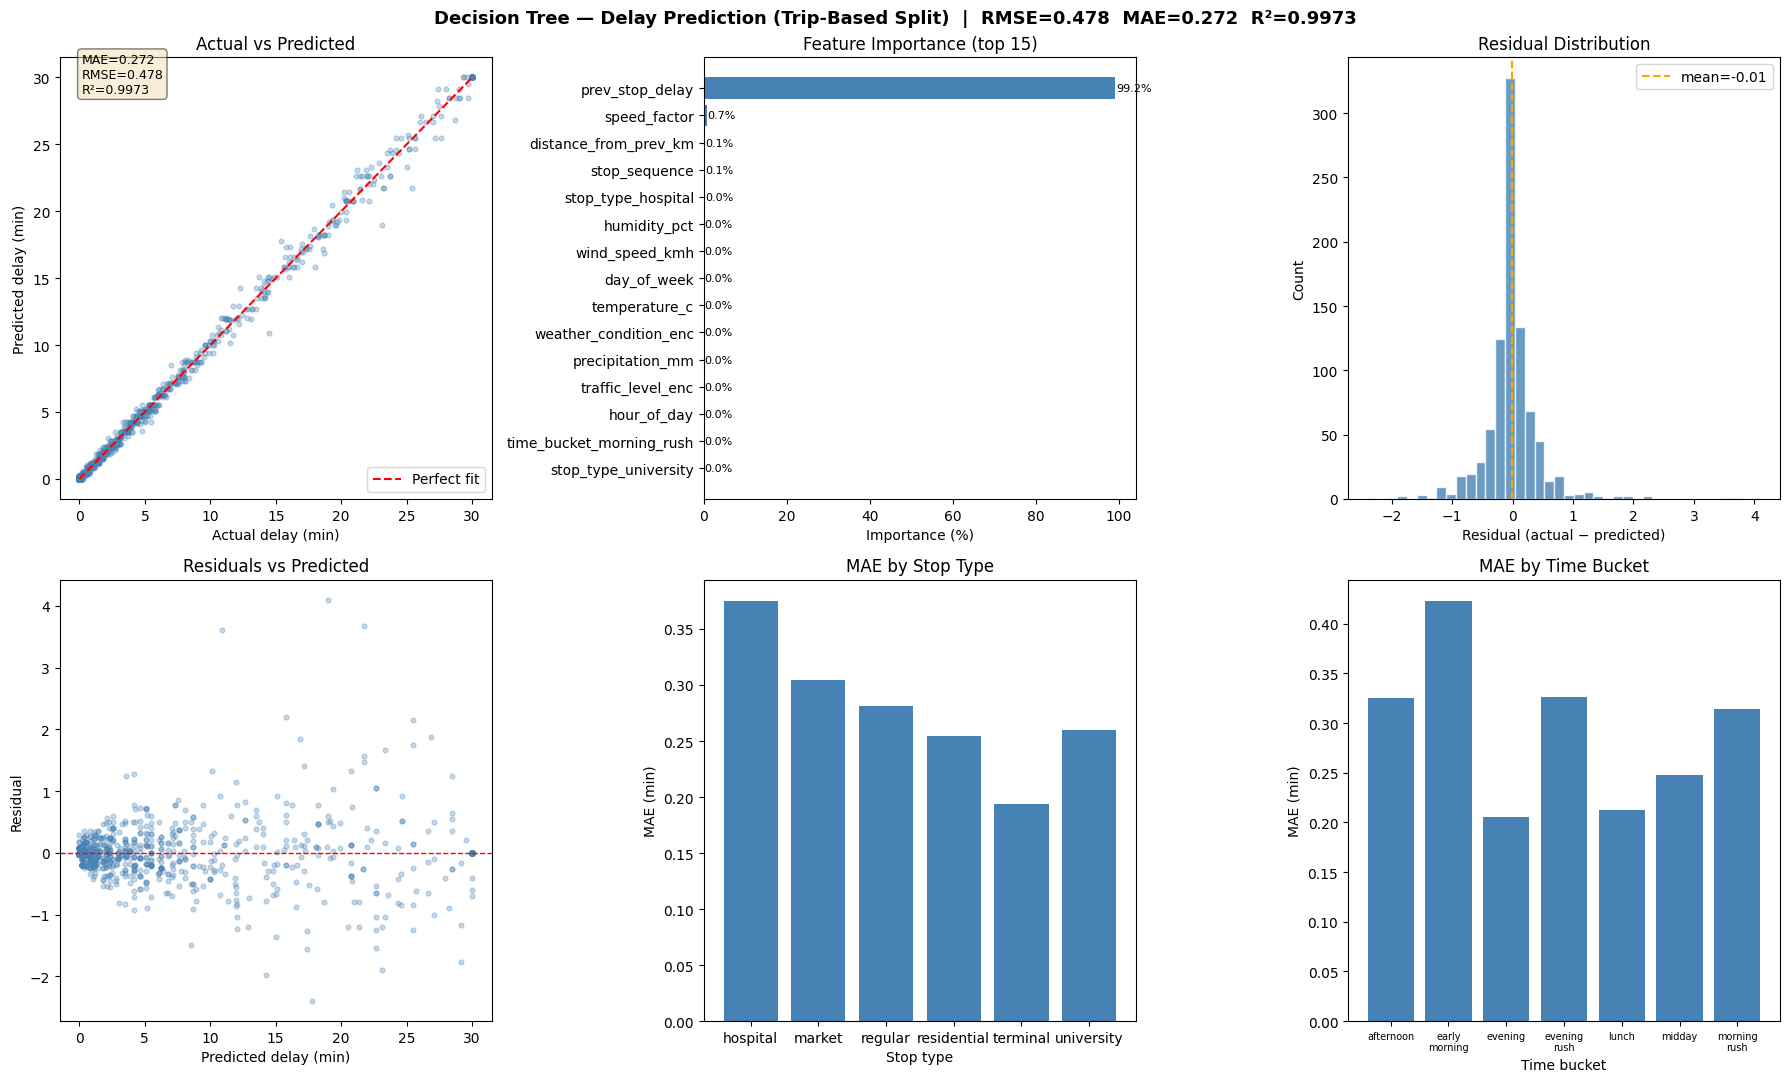

✅ Saved: ../data/results/model1_decision_tree_trip_based_results.png
   TRIP-BASED RESULTS -> MAE=0.272  RMSE=0.478  R²=0.9973


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

# ── 1. LOAD DATA ──────────────────────────────────────────────
df = pd.read_csv('../data/model1_dataset.csv')
arrivals = pd.read_csv('../data/stop_arrivals.csv')[['trip_id']]

# Add trip_id to main dataframe (assuming same row order)
df = df.copy()
df['trip_id'] = arrivals['trip_id'].values

# Features / target
X = df.drop(columns=['target_delay_min', 'traffic_level', 'weather_condition', 'trip_id'])
y = df['target_delay_min']

# ── 2. TRIP-BASED SPLIT ───────────────────────────────────────
unique_trips = df['trip_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_trips)

split_idx = int(len(unique_trips) * 0.8)
train_trips = set(unique_trips[:split_idx])
val_trips   = set(unique_trips[split_idx:])

train_mask = df['trip_id'].isin(train_trips)
val_mask   = df['trip_id'].isin(val_trips)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Unique trips       : {len(unique_trips)}")
print(f"Train trips        : {len(train_trips)}")
print(f"Validation trips   : {len(val_trips)}")
print(f"Train rows         : {len(X_train)}")
print(f"Validation rows    : {len(X_val)}")
print(f"Trip overlap       : {len(train_trips & val_trips)}")  # should be 0

os.makedirs('../data/results', exist_ok=True)

# ── 3. MODELS ─────────────────────────────────────────────────
models = {
    'LightGBM': lgb.LGBMRegressor(
        objective='regression',
        metric='mae',
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        min_child_samples=20,
        verbose=-1,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ),
}

# ── 4. TRAIN & PLOT EACH MODEL ────────────────────────────────
for name, model in models.items():
    print(f"\nTraining {name} on TRIP-BASED split...")

    if name == 'LightGBM':
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_pred = np.clip(y_pred, 0, 30)

    mae  = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2   = r2_score(y_val, y_pred)

    # ── FEATURE IMPORTANCE ────────────────────────────────────
    importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    total_imp = importance['importance'].sum()
    if total_imp > 0:
        importance['pct'] = importance['importance'] / total_imp * 100
    else:
        importance['pct'] = 0

    # ── RESIDUALS ─────────────────────────────────────────────
    residuals = y_val.values - y_pred

    # ── PLOT ──────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(
        f'{name} — Delay Prediction (Trip-Based Split)  |  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}',
        fontsize=13,
        fontweight='bold'
    )

    # 1. Actual vs Predicted
    ax = axes[0, 0]
    ax.scatter(y_val, y_pred, alpha=0.3, s=12, color='steelblue')
    ax.plot([0, 30], [0, 30], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual delay (min)')
    ax.set_ylabel('Predicted delay (min)')
    ax.set_title('Actual vs Predicted')
    ax.legend()
    ax.text(
        0.05, 0.92,
        f'MAE={mae:.3f}\nRMSE={rmse:.3f}\nR²={r2:.4f}',
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

    # 2. Feature Importance
    ax = axes[0, 1]
    bars = ax.barh(importance['feature'], importance['pct'], color='steelblue')
    ax.set_xlabel('Importance (%)')
    ax.set_title('Feature Importance (top 15)')
    ax.invert_yaxis()

    for bar, pct in zip(bars, importance['pct']):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%',
            va='center',
            fontsize=8
        )

    # 3. Residual Distribution
    ax = axes[0, 2]
    ax.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(
        residuals.mean(),
        color='orange',
        linestyle='--',
        label=f'mean={residuals.mean():.2f}'
    )
    ax.set_xlabel('Residual (actual − predicted)')
    ax.set_ylabel('Count')
    ax.set_title('Residual Distribution')
    ax.legend()

    # 4. Residuals vs Predicted
    ax = axes[1, 0]
    ax.scatter(y_pred, residuals, alpha=0.3, s=12, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted delay (min)')
    ax.set_ylabel('Residual')
    ax.set_title('Residuals vs Predicted')

    # 5. MAE by Stop Type
    ax = axes[1, 1]
    stop_cols = [c for c in X.columns if c.startswith('stop_type_')]
    stop_mae = {}

    for col in stop_cols:
        mask = X_val[col] == 1
        if mask.sum() > 0:
            label = col.replace('stop_type_', '')
            stop_mae[label] = mean_absolute_error(y_val[mask], y_pred[mask])

    ax.bar(stop_mae.keys(), stop_mae.values(), color='steelblue')
    ax.set_xlabel('Stop type')
    ax.set_ylabel('MAE (min)')
    ax.set_title('MAE by Stop Type')

    # 6. MAE by Time Bucket
    ax = axes[1, 2]
    time_cols = [c for c in X.columns if c.startswith('time_bucket_')]
    time_mae = {}

    for col in time_cols:
        mask = X_val[col] == 1
        if mask.sum() > 0:
            label = col.replace('time_bucket_', '').replace('_', '\n')
            time_mae[label] = mean_absolute_error(y_val[mask], y_pred[mask])

    ax.bar(time_mae.keys(), time_mae.values(), color='steelblue')
    ax.set_xlabel('Time bucket')
    ax.set_ylabel('MAE (min)')
    ax.set_title('MAE by Time Bucket')
    plt.setp(ax.xaxis.get_majorticklabels(), fontsize=7)

    plt.tight_layout()

    fname = f'../data/results/model1_{name.lower().replace(" ", "_")}_trip_based_results.png'
    plt.savefig(fname, dpi=150)
    plt.show()

    print(f"✅ Saved: {fname}")
    print(f"   TRIP-BASED RESULTS -> MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")

In [21]:
print("hello")

hello
